# Set up

In [1]:
import matplotlib.pyplot as plt

In [2]:
import os 
os.environ['GEOMSTATS_BACKEND'] = 'pytorch'

import geomstats.backend as gs
from geomstats.geometry.pre_shape import KendallShapeMetric, PreShapeBundle, PreShapeMetric, PreShapeSpace
from geomstats.visualization import KendallDisk

In [4]:
from pt import parallel_transport
from klle import KendallHorizontalBundle, KendallLocallyLinearEmbedding

# Locally Linear Embedding in Kendall shape spaces

## Step 1: K-Nearest Neighbours

In [5]:
#Initialisation
KLLE = KendallLocallyLinearEmbedding(k_landmarks=3, m_ambient=3)
KD = KendallDisk()

In [6]:
#Data
X = KLLE.manifold.random_point(10)
i = 0

In [7]:
#Method
neighbours = KLLE.nearest_neighbours(points=X, k_neighbours=3)

/home/emaignant/miniconda3/envs/rlle/lib/python3.14/site-packages/geomstats/_backend/pytorch/__init__.py:660: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1770245732410/work/torch/csrc/utils/tensor_new.cpp:654.)
  return _torch.sparse.FloatTensor(


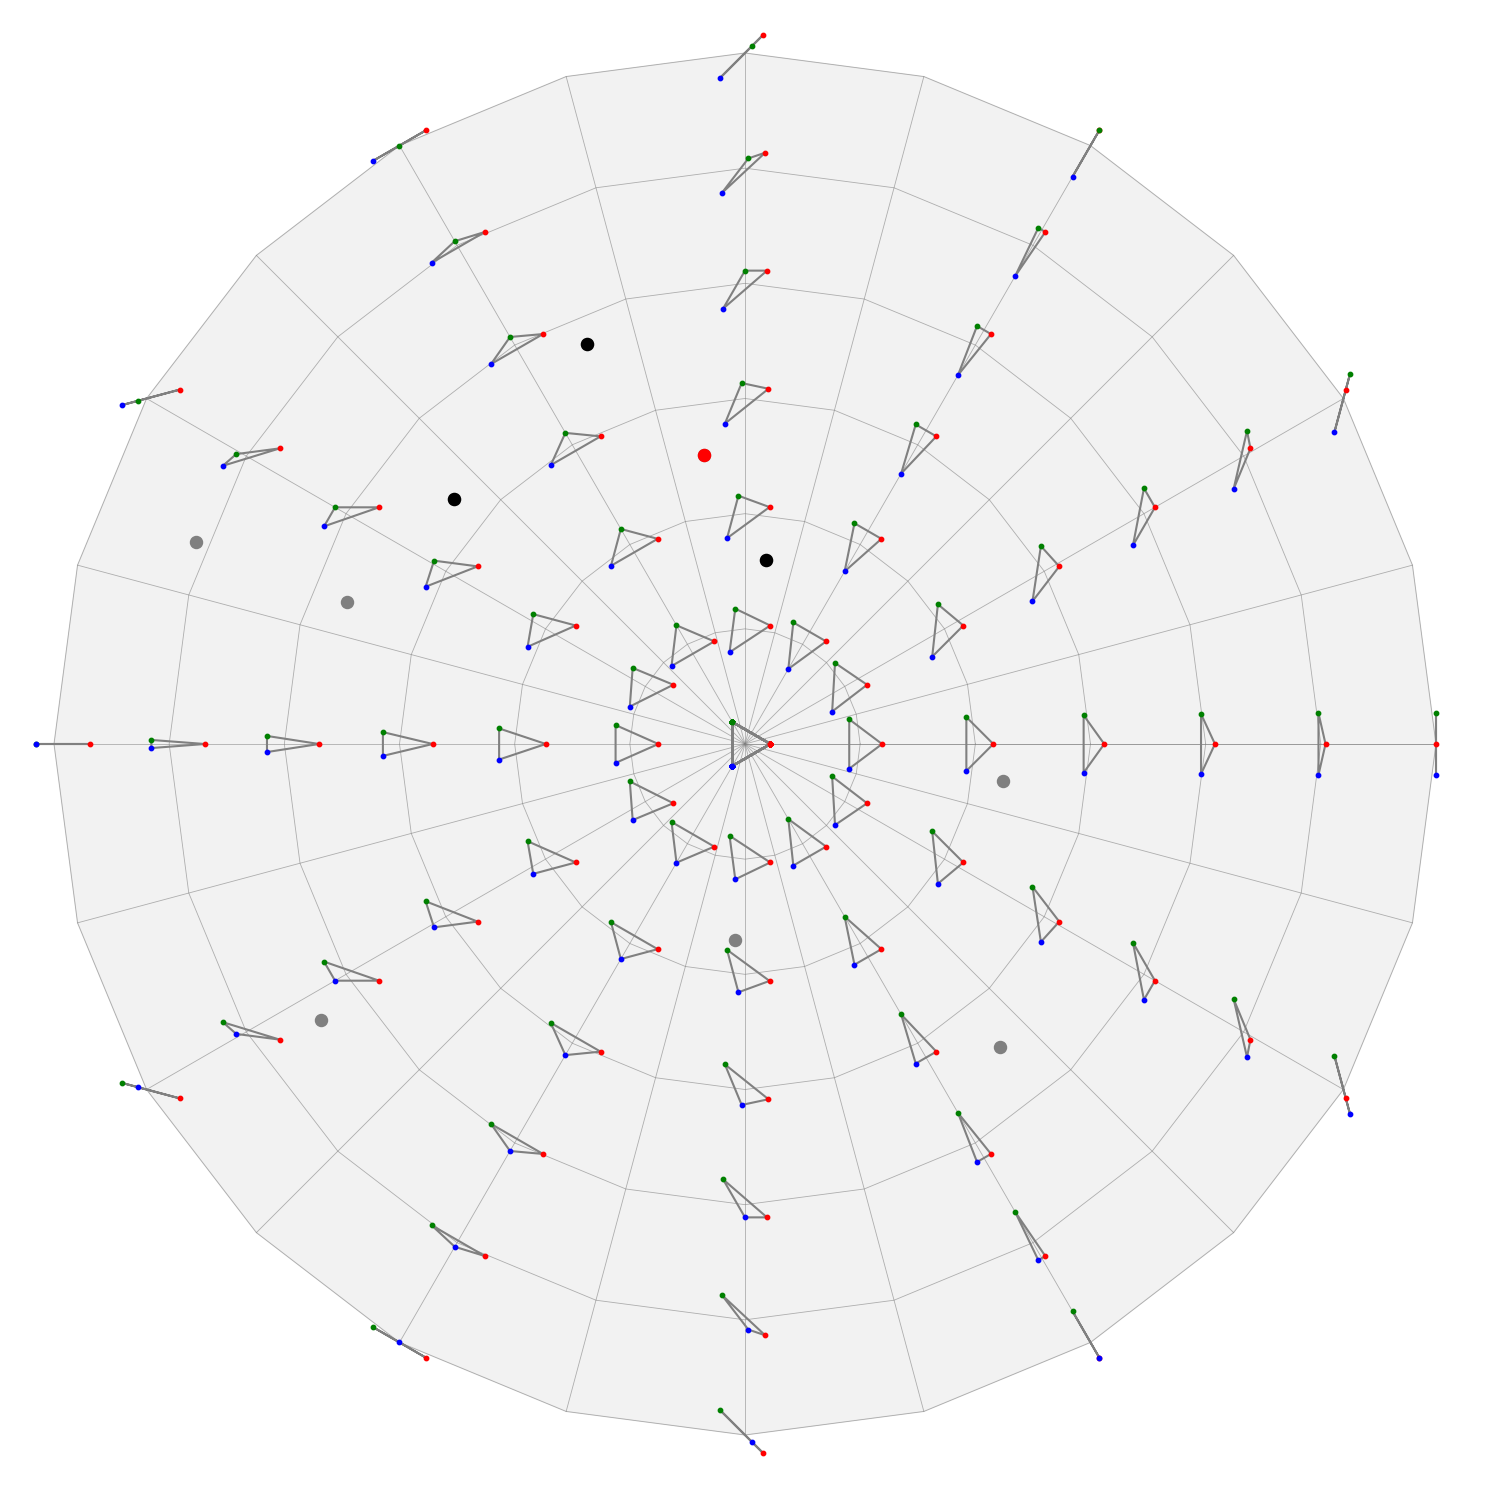

In [8]:
#Visualisation
fig = plt.figure(figsize=(15, 15))

KD.draw()

KD.clear_points()
KD.add_points(X)
KD.draw_points(color='grey', s=75)

KD.clear_points()
KD.add_points(X[i])
KD.draw_points(color='r', s=75)

KD.clear_points()
KD.add_points(X[neighbours[i]])
KD.draw_points(color='k', s=75)

## Step 2: reconstruction weights

We implement an augmented Lagrangian method to solve the following minimisation problems

\begin{equation}
    \begin{split}
        \text{minimise} & \quad \|v_i\|^2\\\\
        \text{w. r. t.}& \quad w_{ij}=0\quad\text{if }x_j\text{ is not a neighbour of }x_j\\
        & \quad\sum_j w_{ij} = 1\\
        & \quad\sum_j  w_{ij} u_{ij}=0\\
        & \quad x_j = \exp(a_{ij})\cdot\text{Exp}_{\widehat x_i}\big(P_{x_i,\widehat x_i}(u_{ij})\big)\quad\text{for all }j.
    \end{split}
\label{pb1}\tag{P}
\end{equation}

where $\hat x_i=\text{Exp}_{x_i}(v_i)$, $a_{ij}\in\mathfrak{so}(m)$ and $v_i, u_{ij}\in \text{Hor}_{x_i}\mathcal{S}^k_m$.

In [9]:
#Method
aligned = KLLE.hor_bundle.align(X[neighbours[i]], X[i])
projected = KLLE.barycentric_projection(point=X[i], ref_points=aligned)

#### Example: isobarycenter

In [10]:
#Data
equi = KD.centre

red_iso = equi - gs.pi / 16. * gs.array([[1., 0., 0.], [0., 0., 0.],[0., 0., 0.]])
green_iso = equi - gs.pi / 16. * gs.array([[0., 0., 0.], [- .5, gs.sqrt(3.) / 2., 0.], [0., 0., 0.]])
blue_iso = equi - gs.pi / 16. * gs.array([[0., 0., 0.], [0., 0., 0.], [- .5, - gs.sqrt(3.) / 2., 0.]])
iso = KLLE.manifold.projection(gs.array([red_iso, green_iso, blue_iso]))

In [11]:
#Results
skew, hor_vec, hor_vecs, weights = KLLE.barycentric_projection(point=equi, ref_points=iso)
print("weights =", weights)

weights = tensor([0.3333, 0.3333, 0.3333])


#### Example: geodesic projection

In [12]:
#Data
X = KLLE.manifold.random_point(3)

In [13]:
#Results
aligned = KLLE.hor_bundle.align(X[1:], X[0])
skew, hor_vecs, hor_vec, weights = KLLE.barycentric_projection(point=X[0], ref_points=aligned)
print(weights)

tensor([0.5901, 0.4098])


In [14]:
#Geodesic
speed = KLLE.metric.log(X[2], X[1])
curve = gs.array([KLLE.metric.exp(t * speed, X[1]) for t in gs.linspace(0., 3., 100)])
projected = KLLE.metric.exp(weights[1] * speed, X[1])
projection = gs.array([KLLE.metric.exp(t * hor_vec, X[0]) for t in gs.linspace(0., 1., 100)])

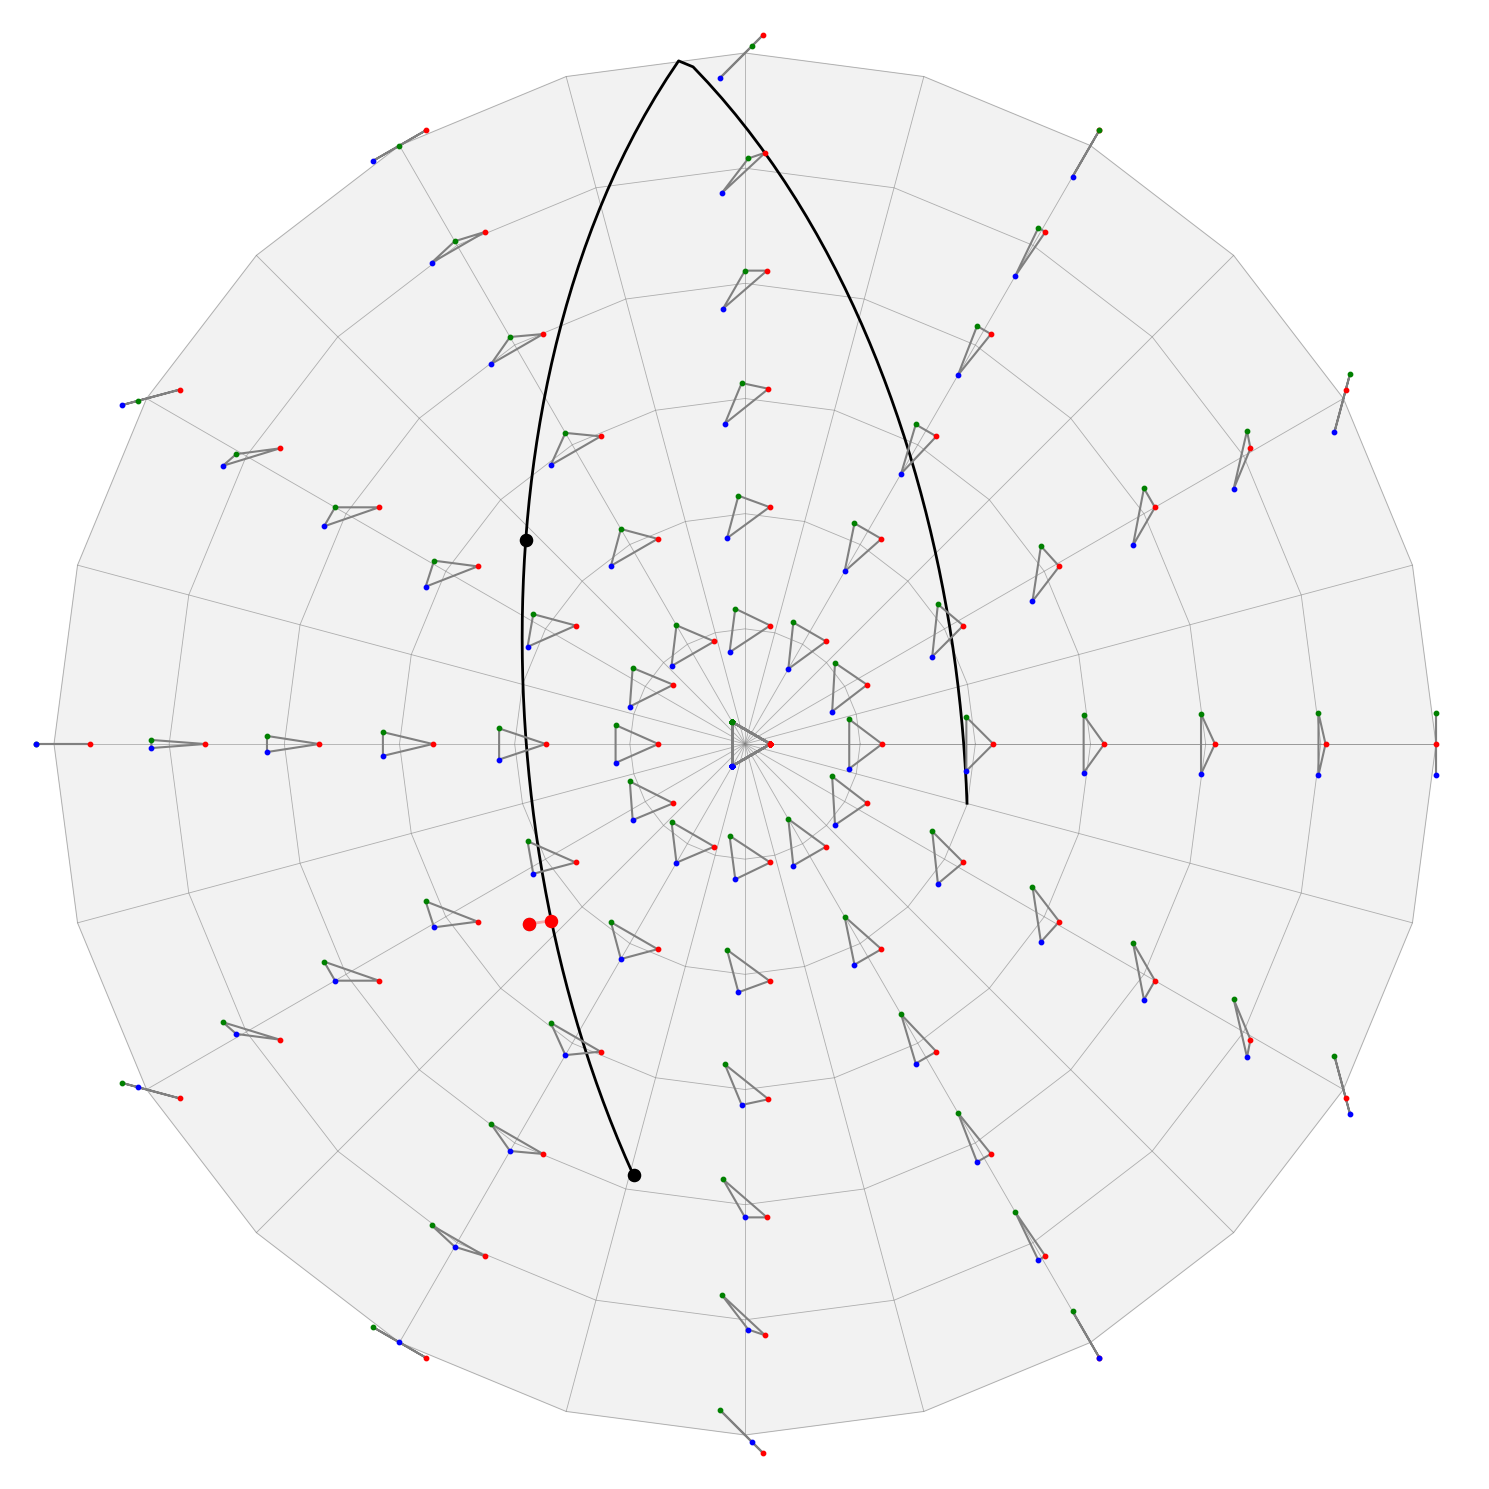

In [15]:
#Visualisation
fig = plt.figure(figsize=(15, 15))

KD.draw()

KD.clear_points()
KD.add_points(X)
KD.draw_points(color='grey', s=75)

KD.clear_points()
KD.add_points(X[0])
KD.draw_points(color='r', s=75)

KD.clear_points()
KD.add_points(curve)
KD.draw_curve(color='k', lw=2)

KD.clear_points()
KD.add_points(X[1:])
KD.draw_points(color='k', s=75)

KD.clear_points()
KD.add_points(projected)
KD.draw_points(color='r', s=75)

KD.clear_points()
KD.add_points(projection)
KD.draw_curve(color='r', lw=2, alpha=.3)

## Step 3: embedding coordinates. 

Embedding coordinates $y$ should minimise the cost

$$\sum_i\|y_i-\sum_j w_{ij}y_j\|^2$$

In this Riemannian LLE, it is computed the same way it would done in Euclidean LLE.

In [16]:
KLLE = KendallLocallyLinearEmbedding(k_landmarks=3, m_ambient=3)
KD = KendallDisk()

In [17]:
#Data
n_data = 20
mean_1 = KLLE.manifold.projection(gs.array([[-1., 0., 0.], [1, 0., 0.], [0., 1.3, 0.]]))
mean_2 = KLLE.manifold.projection(gs.array([[-1., 0., 0.], [0., 2.3, 0.], [1., 0., 0.]]))
#mean_1 = KLLE.manifold.projection(gs.array([[-1., 0., 0.], [1, 0., 0.], [0., .5, 0.]]))
#mean_2 = KLLE.manifold.projection(gs.array([[-1., 0., 0.], [0., 4.5, 0.], [1., 0., 0.]]))
gaussian_1 = gs.random.multivariate_normal(mean_1, .001 * gs.eye(3), n_data // 2)
gaussian_2 = gs.random.multivariate_normal(mean_2, .001 * gs.eye(3), n_data // 2)
X = KLLE.manifold.projection(gs.array(list(gaussian_1) + list(gaussian_2)))

/tmp/ipykernel_1849804/202185314.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('spring', 1000)


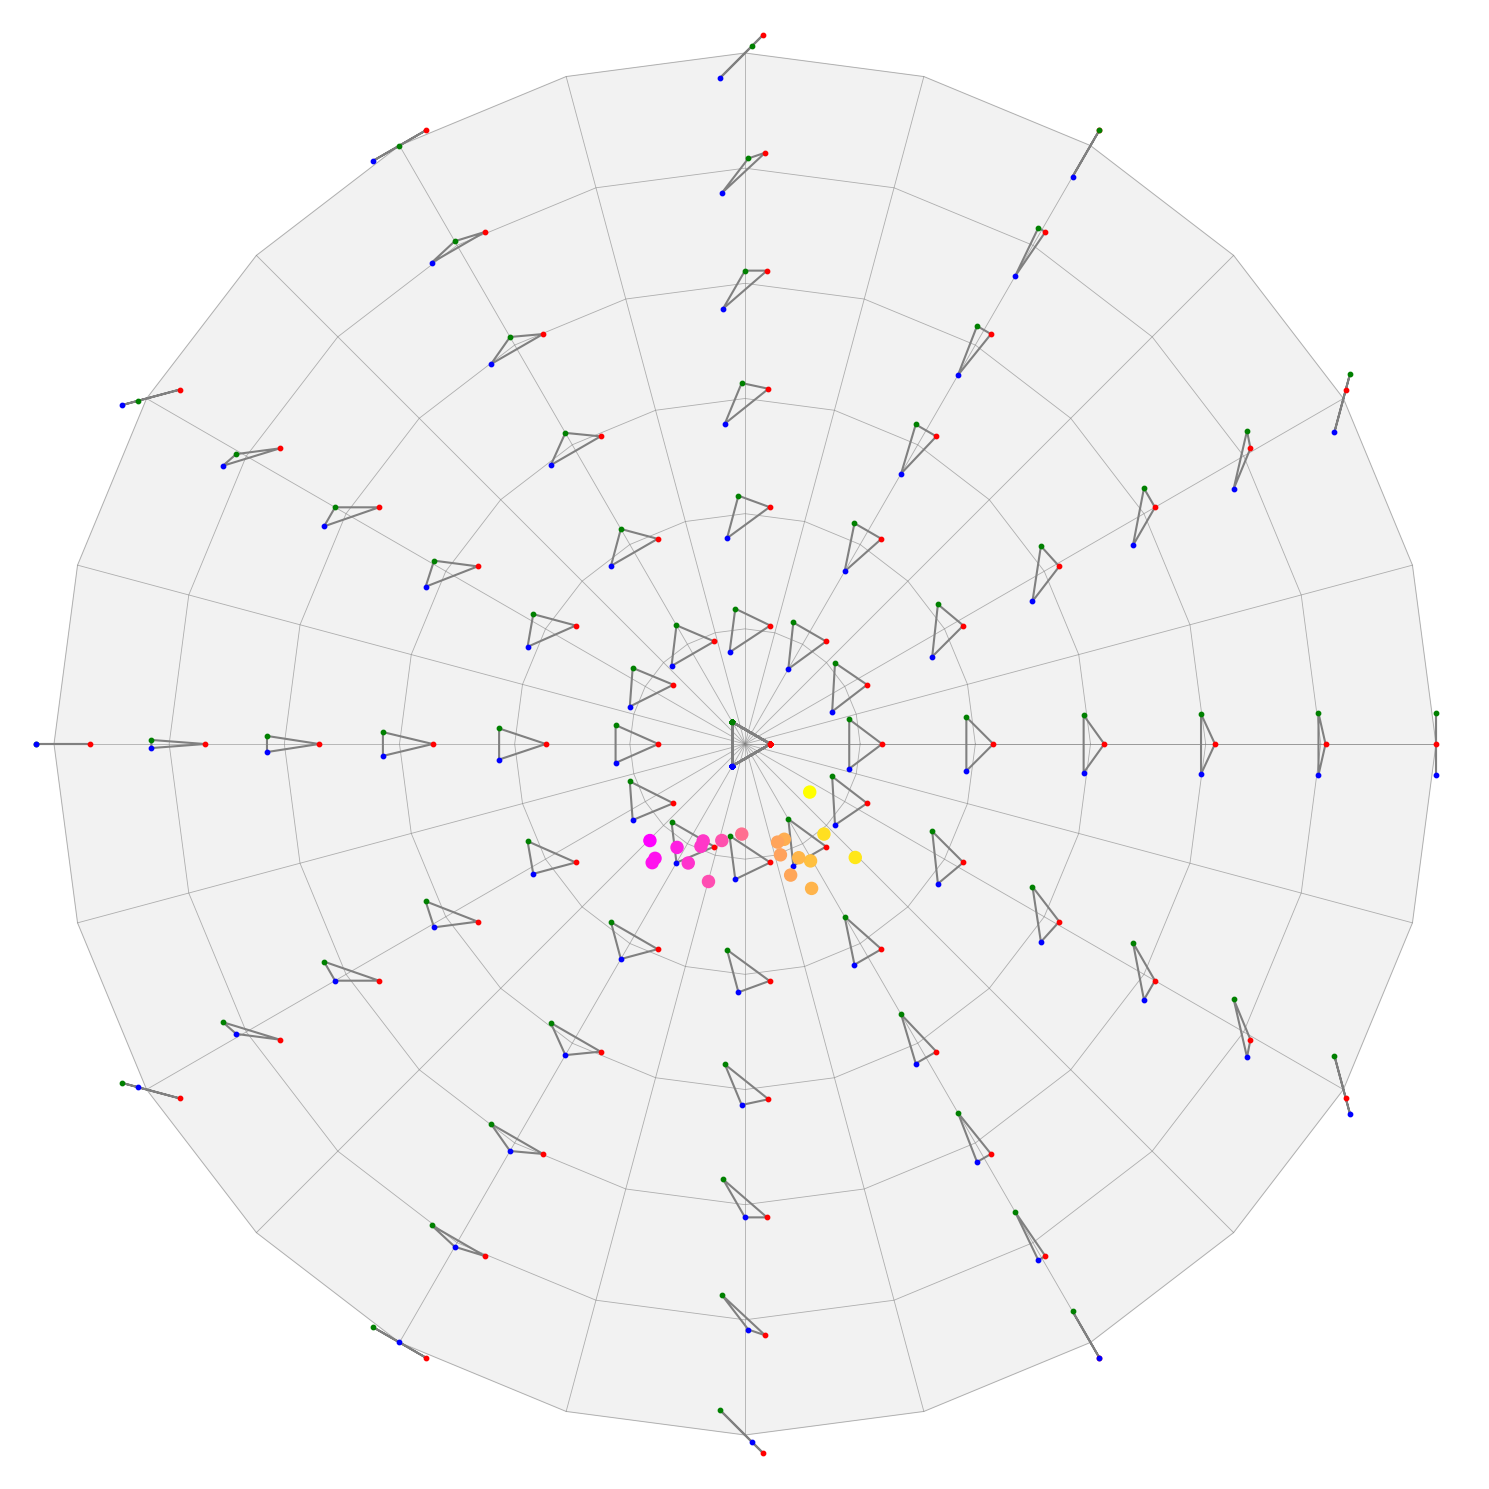

In [18]:
#Visualisation
planar = KD.convert_to_planar_coordinates(X)

fig = plt.figure(figsize=(15, 15))
from matplotlib import cm
colormap = cm.get_cmap('spring', 1000)
r = KD.convert_to_polar_coordinates(X)[1]
colors = colormap([0] + list((r - min(r)) / (max(r) - min(r))))[1:]

KD.draw()

KD.clear_points()
KD.add_points(X)
KD.draw_points(color=colors, s=75, zorder=1)

In [19]:
polar = KD.convert_to_polar_coordinates(X)
theta, phi = polar[0], polar[1]
data3d = []
for t, p in zip(theta, phi):
    data3d.append(gs.array([gs.cos(gs.pi/2-2*t) * gs.cos(p), gs.cos(gs.pi/2-2*t) * gs.sin(p), gs.sin(gs.pi/2-2*t)]))
data3d = gs.array(data3d)

In [20]:
#Method
k_neighbours=3

#rlle1 = KLLE.fit(points=X, k_neighbours=k_neighbours, d_embedding=2)
#print(rlle1)

In [21]:
k_neighbours=8

neighbours = KLLE.nearest_neighbours(points=X, k_neighbours=k_neighbours)
alpha=1E-17
W = gs.zeros((n_data, n_data))

for i in range(n_data):
    aligned = KLLE.hor_bundle.align(X[neighbours[i]], X[i])
    centred = gs.array([gs.flatten(KLLE.hor_metric.log(x, X[i])) for x in aligned])
    covariance_mat = centred @ gs.transpose(centred)
    covariance_mat = covariance_mat# + alpha * gs.trace(covariance_mat) * gs.eye(k_neighbours)
    weights = gs.linalg.inv(covariance_mat) @ gs.ones(k_neighbours)
    for(j, w) in zip(neighbours[i], weights): W[i, j] = w / gs.sum(weights)
        
sparse_mat = gs.transpose(gs.eye(n_data) - W) @ (gs.eye(n_data) - W)
[eigen_val, eigen_vec] = gs.linalg.eigh(sparse_mat)
print(eigen_val)

rlle2 = KLLE.embedding_coordinates(weights=W, d_embedding=2)
print(rlle2)

tensor([-8.5780e-14,  3.7816e-08,  2.3153e-07,  4.5412e-05,  2.4558e-02,
         9.2932e-02,  3.7479e-01,  4.7064e-01,  7.6561e-01,  1.9949e+00,
         2.4609e+00,  3.0774e+00,  4.7032e+00,  6.2644e+00,  7.5964e+00,
         1.2310e+01,  3.9830e+01,  1.8317e+02,  2.1635e+02,  2.0915e+03])
tensor([[ 0.3040, -0.1370],
        [ 0.1805,  0.0860],
        [ 0.3028, -0.1856],
        [ 0.0611,  0.1815],
        [ 0.3669,  0.0474],
        [ 0.1160,  0.1024],
        [ 0.1767, -0.1610],
        [ 0.2552, -0.0028],
        [ 0.1749,  0.0273],
        [ 0.0598, -0.3449],
        [-0.3237, -0.3750],
        [-0.3964, -0.0207],
        [-0.2273,  0.2238],
        [-0.1010,  0.1496],
        [-0.2494, -0.0754],
        [-0.1278, -0.0225],
        [-0.1993, -0.0454],
        [-0.0850,  0.1155],
        [-0.0726,  0.6753],
        [-0.2156, -0.2386]])


In [22]:
#Align embeddings
def align_affine(embedding, reference):
    
    def error(var):
        mat = var[:4].reshape((2, 2))
        vec = var[4:]
        return(gs.linalg.norm(embedding @ mat + vec - reference))
    
    var0 = gs.random.rand(6)
    res = minimize(fun=error, x0=var0, method='BFGS', options={'maxiter' : 100})
    
    return(embedding @ res.x[:4].reshape((2, 2)) + res.x[4:], res.fun)

In [23]:
#Align embeddings
def align_rigid(embedding, reference):
    
    def error(var):
        scale = var[0]
        theta = var[1] - int(var[1] / (2. * gs.pi)) * 2. * gs.pi
        rot = gs.array([[gs.cos(theta), gs.sin(theta)], [-gs.sin(theta), gs.cos(theta)]])
        vec = var[2:]
        err = gs.linalg.norm(scale * embedding @ rot + vec - reference)
        return(err)
    
    var0 = gs.array([1., 0., 0., 0.])
    res = minimize(fun=error, x0=var0, method='BFGS', options={'maxiter' : 100})
    
    scale_star = res.x[0]
    theta_star = res.x[1] - int(res.x[1] / (2. * gs.pi)) * 2. * gs.pi
    rot_star = gs.array([[gs.cos(theta_star), gs.sin(theta_star)], [-gs.sin(theta_star), gs.cos(theta_star)]])
    vec_star = res.x[2:]
    
    return(scale_star * embedding @ rot_star + vec_star, res.fun)

In [24]:
from scipy.optimize import minimize, NonlinearConstraint

0.2982119690250414
tensor(0.0005)
tensor(5.6639e-05)


/tmp/ipykernel_1849804/2388457464.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  err = gs.linalg.norm(scale * embedding @ rot + vec - reference)
/tmp/ipykernel_1849804/2388457464.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return(scale_star * embedding @ rot_star + vec_star, res.fun)


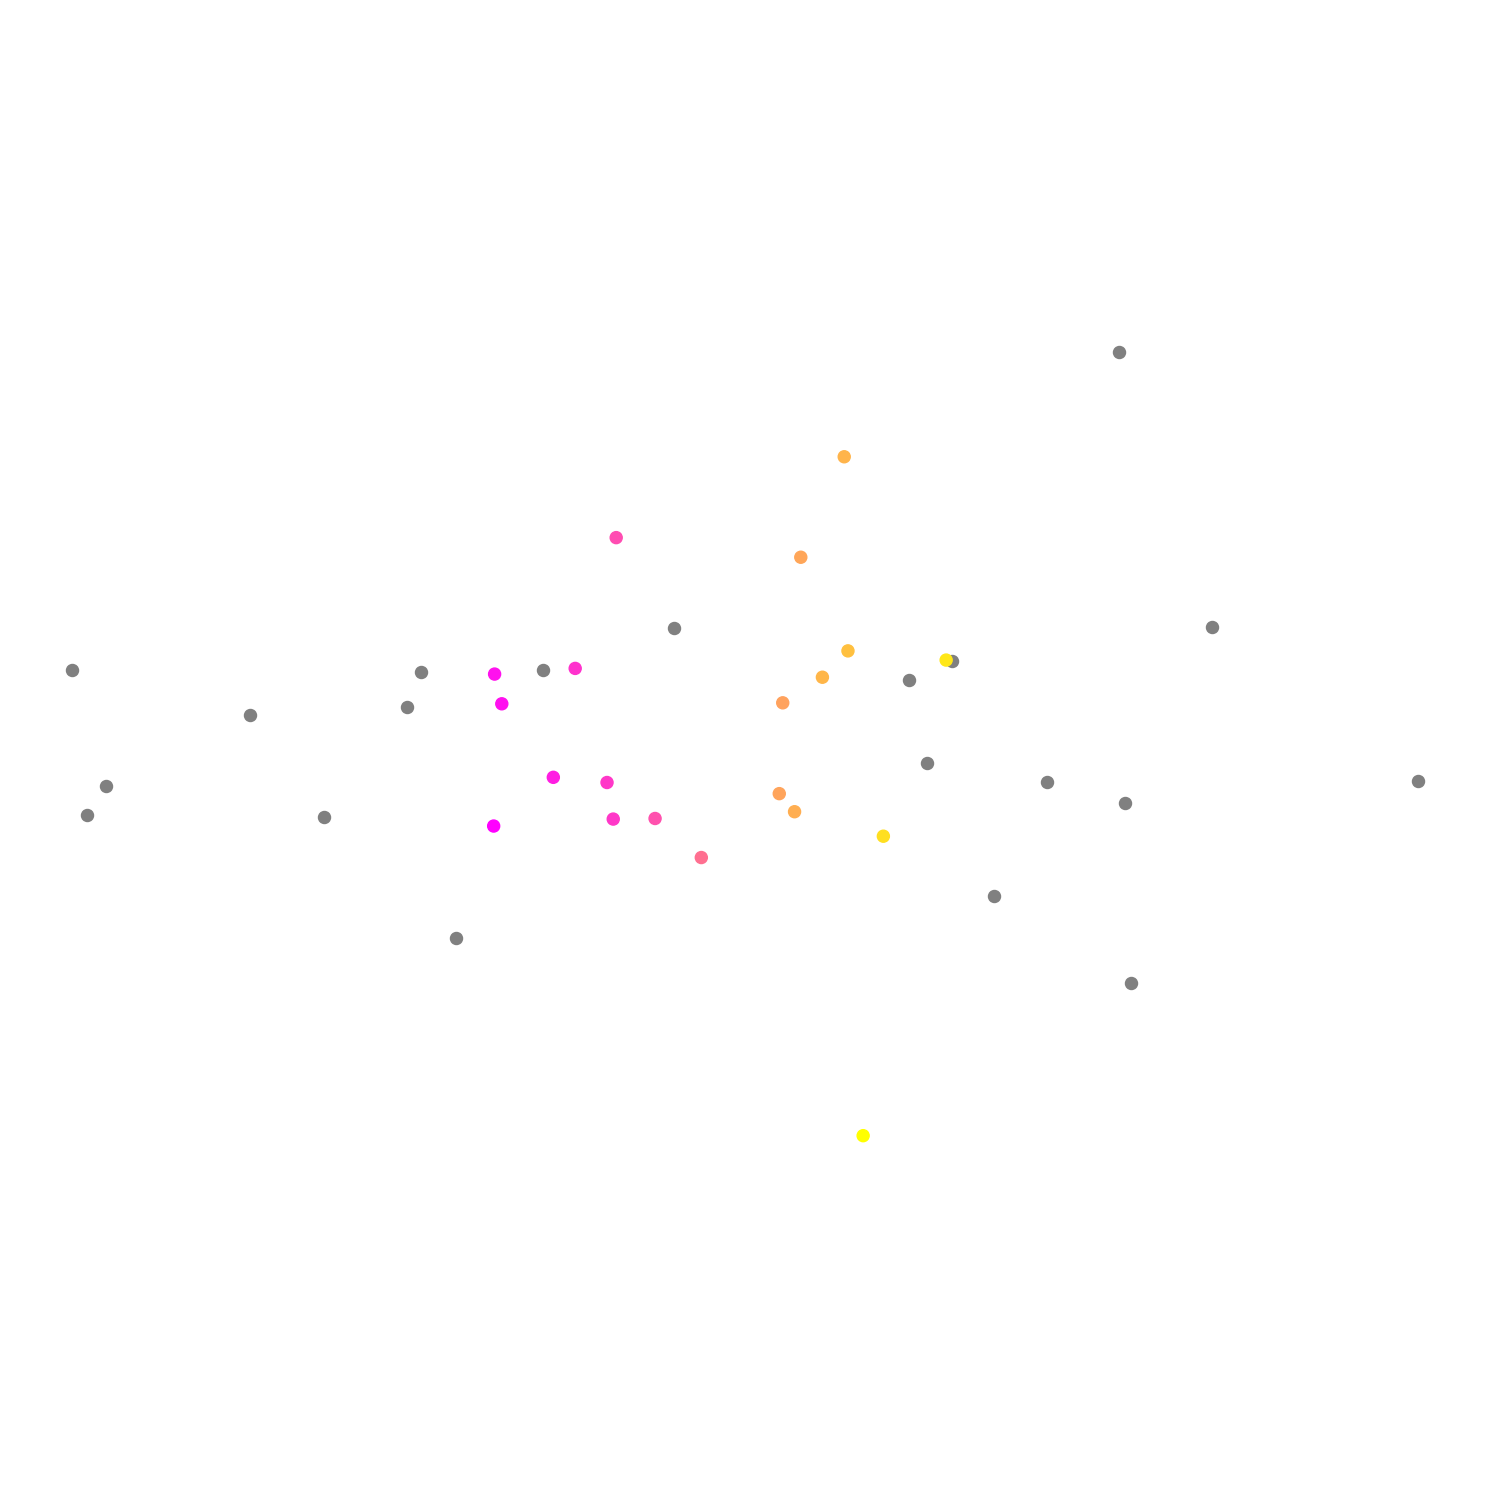

In [25]:
#Riemannian Locally Linear Embedding
procruste, procruste_dist = align_rigid(rlle2, planar)
print(procruste_dist)
print(gs.linalg.norm(W @ rlle2 - rlle2))
print(gs.linalg.norm(W @ procruste - procruste))

#Aligned embedding
fig = plt.figure(figsize=(15, 15))
plt.scatter(planar[:, 0], planar[:, 1], color='grey', s=75)
plt.scatter(procruste[:, 0], procruste[:, 1], color=colors, s=75, zorder=2)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()

In [26]:
#Compute Euclidean weights and LLE
k_neighbours=8

neighbours = KLLE.nearest_neighbours(points=X, k_neighbours=k_neighbours)
alpha=1E-12
W = gs.zeros((n_data, n_data))

for i in range(n_data):
    aligned = KLLE.hor_bundle.align(X[neighbours[i]], X[i])
    #aligned = X[neighbours[i]]
    centred = gs.array([gs.flatten(x) for x in aligned]) - gs.flatten(X[i])
    covariance_mat = centred @ gs.transpose(centred)
    covariance_mat = covariance_mat# + alpha * gs.trace(covariance_mat) * gs.eye(k_neighbours)
    weights = gs.linalg.inv(covariance_mat) @ gs.ones(k_neighbours)
    for(j, w) in zip(neighbours[i], weights): W[i, j] = w / gs.sum(weights)
        
sparse_mat = gs.transpose(gs.eye(n_data) - W) @ (gs.eye(n_data) - W)
[eigen_val, eigen_vec] = gs.linalg.eigh(sparse_mat)
print(eigen_val)

lle = KLLE.embedding_coordinates(weights=W, d_embedding=2)

tensor([-2.0333e-16,  1.5802e-09,  6.7679e-09,  8.5263e-07,  1.6642e-04,
         7.4136e-03,  1.2082e-01,  3.6192e-01,  6.6666e-01,  1.1415e+00,
         1.6384e+00,  3.9705e+00,  5.4657e+00,  6.1914e+00,  6.5742e+00,
         9.0916e+00,  1.3835e+01,  2.2815e+01,  3.5119e+01,  6.2887e+01])


tensor(0.1840)
tensor([[-1.3371e-06,  1.9294e-07],
        [-2.8268e-06, -5.0920e-06],
        [-5.1296e-06,  2.9481e-06],
        [-1.1478e-08, -1.4074e-08],
        [ 1.6398e-06, -1.2054e-06],
        [ 2.5225e-09, -9.6542e-09],
        [-1.4612e-06, -5.5442e-08],
        [-1.8619e-08, -8.3541e-06],
        [-3.8735e-06, -1.0004e-05],
        [ 3.4616e-07,  7.3259e-07],
        [-1.3255e-07, -2.1322e-06],
        [-4.6212e-07, -9.1229e-08],
        [ 4.6522e-07, -1.0488e-06],
        [-6.6738e-07,  9.2984e-07],
        [ 1.4138e-07, -4.2212e-07],
        [ 2.6140e-07, -9.7966e-07],
        [ 2.0222e-06, -6.2527e-06],
        [ 4.7229e-08,  7.0535e-08],
        [ 1.8769e-07, -3.9889e-07],
        [ 1.6067e-06, -3.4796e-06]])


/tmp/ipykernel_1849804/2388457464.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  err = gs.linalg.norm(scale * embedding @ rot + vec - reference)
/tmp/ipykernel_1849804/2388457464.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return(scale_star * embedding @ rot_star + vec_star, res.fun)


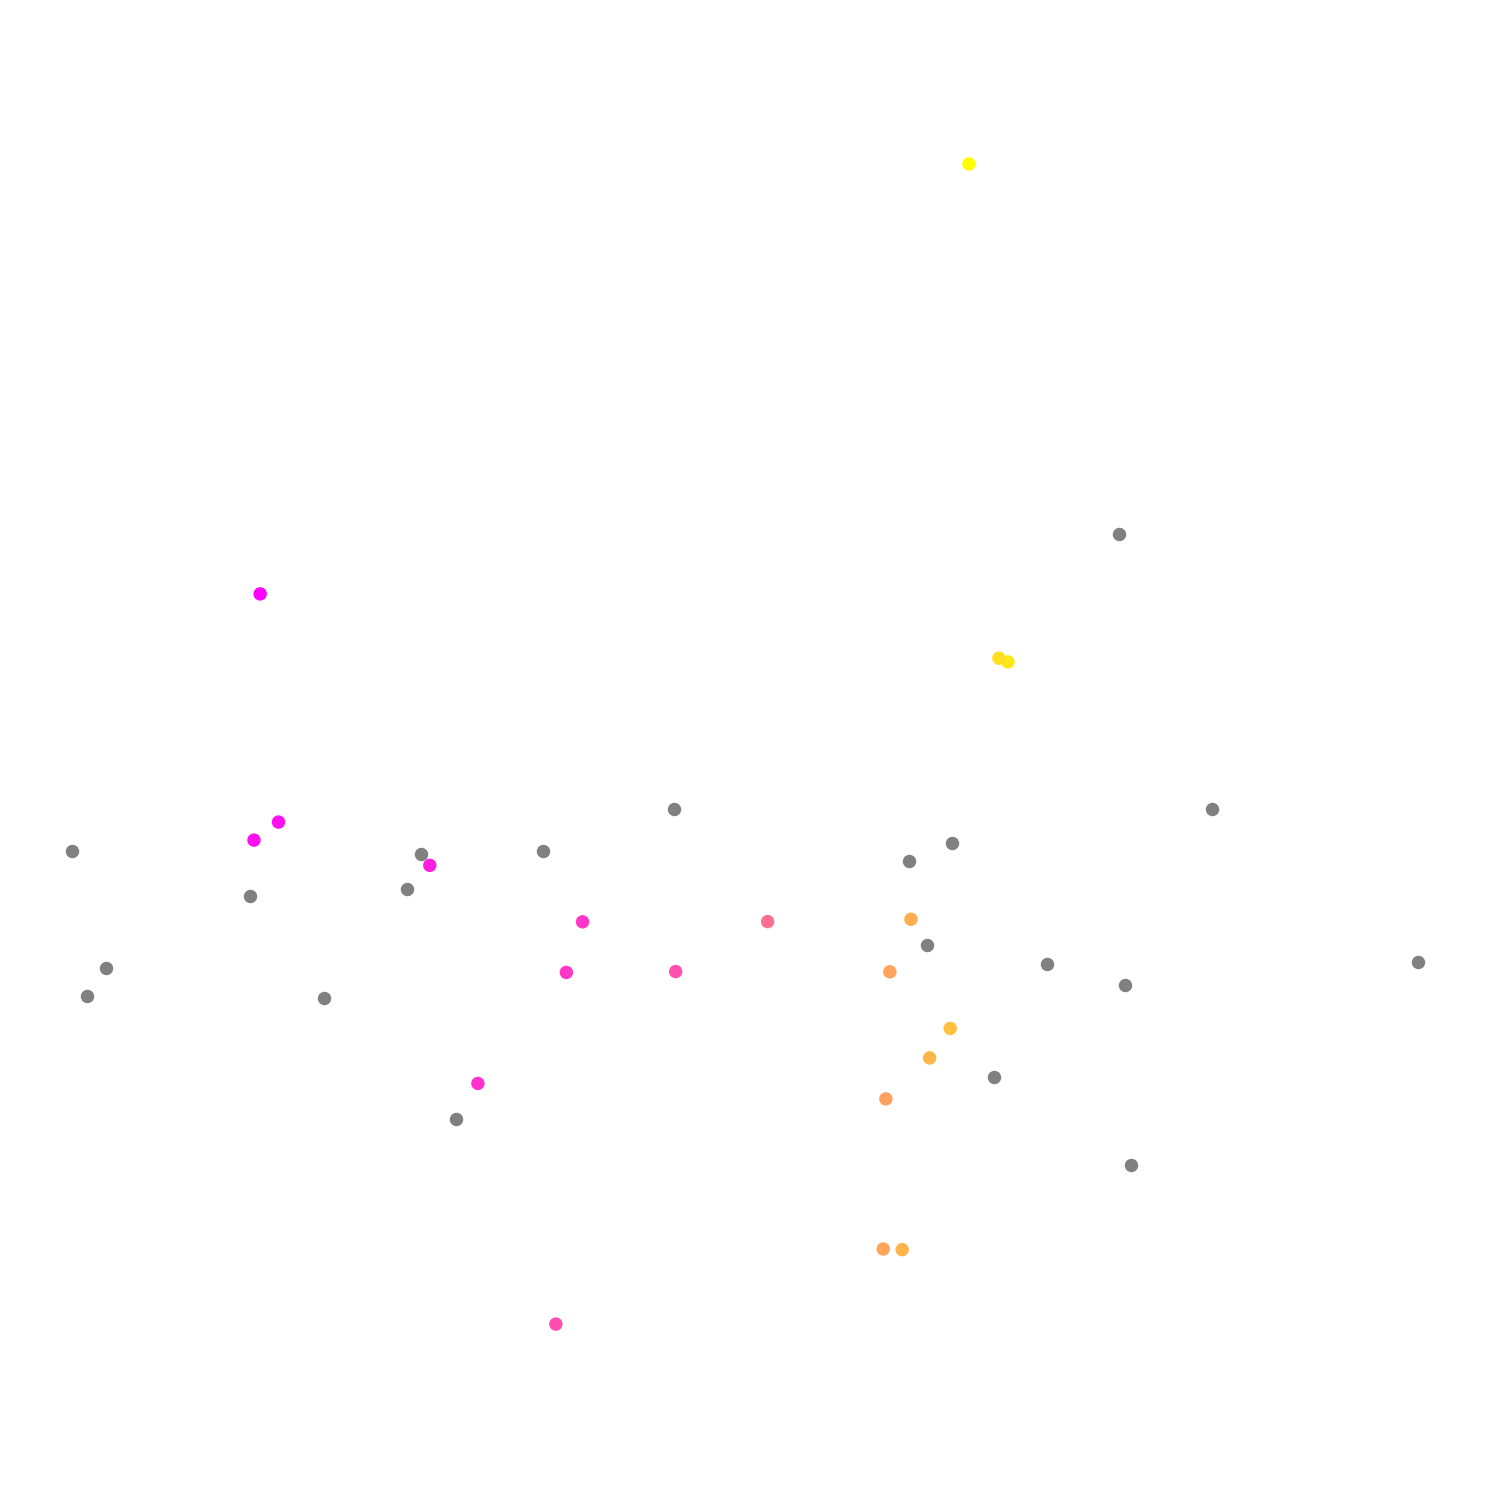

In [27]:
#Euclidean Locally Linear Embedding
procruste, procruste_dist = align_rigid(lle, planar)
print(gs.linalg.norm(procruste - planar))
print(W @ procruste - procruste)


#Aligned embedding
fig = plt.figure(figsize=(15, 15))
plt.scatter(planar[:, 0], planar[:, 1], color='grey', s=75)
plt.scatter(procruste[:, 0], procruste[:, 1], color=colors, s=75, zorder=2)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()

In [28]:
#Conservation of interdistances
dist =  KLLE.metric.dist_pairwise(X)

procruste_lle, procruste_dist = align_rigid(lle, planar)
dist_lle = gs.array([[gs.linalg.norm(procruste_lle[j] - procruste_lle[i]) 
                      for j in range(len(X))] for i in range(len(X))])

procruste_rlle, procruste_dist = align_rigid(rlle2, planar)
dist_rlle = gs.array([[gs.linalg.norm(procruste_rlle[j] - procruste_rlle[i]) 
                       for j in range(len(X))] for i in range(len(X))])

print("Measure of the conservation of the distances in RLLE:", gs.linalg.norm(dist_rlle - dist))
print("Measure of the conservation of the distances in LLE:", gs.linalg.norm(dist_lle - dist))

Measure of the conservation of the distances in RLLE: tensor(1.2214)
Measure of the conservation of the distances in LLE: tensor(0.7461)


/tmp/ipykernel_1849804/2388457464.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  err = gs.linalg.norm(scale * embedding @ rot + vec - reference)
/tmp/ipykernel_1849804/2388457464.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return(scale_star * embedding @ rot_star + vec_star, res.fun)


#### Example: RLLE of 1-dimensionnal structure in a 2-dimensionnal manifold

In [29]:
import networkx as nx
import scipy.integrate as integrate

In [30]:
#Data
n_data = 20
radius = gs.linspace(0., gs.pi / 8, 1000)
theta = gs.linspace(0., 1.5 * gs.pi, 1000)
u_theta = gs.array([gs.cos(t) * KD.ua + gs.sin(t) * KD.na for t in theta])
model = gs.array([gs.hstack((gs.cos(r) * KD.pole + gs.sin(r) * u, gs.zeros((3, 1)))) 
                 for (r, u) in zip(radius, u_theta)])

curv_ab = gs.array([integrate.quad(lambda t: gs.sqrt(1. + 36. * gs.sin(t / 6) ** 2), 0., t_i)[0] for t_i in theta])
times = (gs.linspace(100**(5./3.), 950**(5./3.), n_data))**(3./5.) + gs.random.normal(scale=5., size=n_data)
times = gs.array([int(t) for t in times])

noise = gs.random.multivariate_normal(mean=gs.zeros((3, 3)), cov=.0001 * gs.eye(3), size=n_data)
X = model[times]

/tmp/ipykernel_1849804/2241389979.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap('jet', 1000)


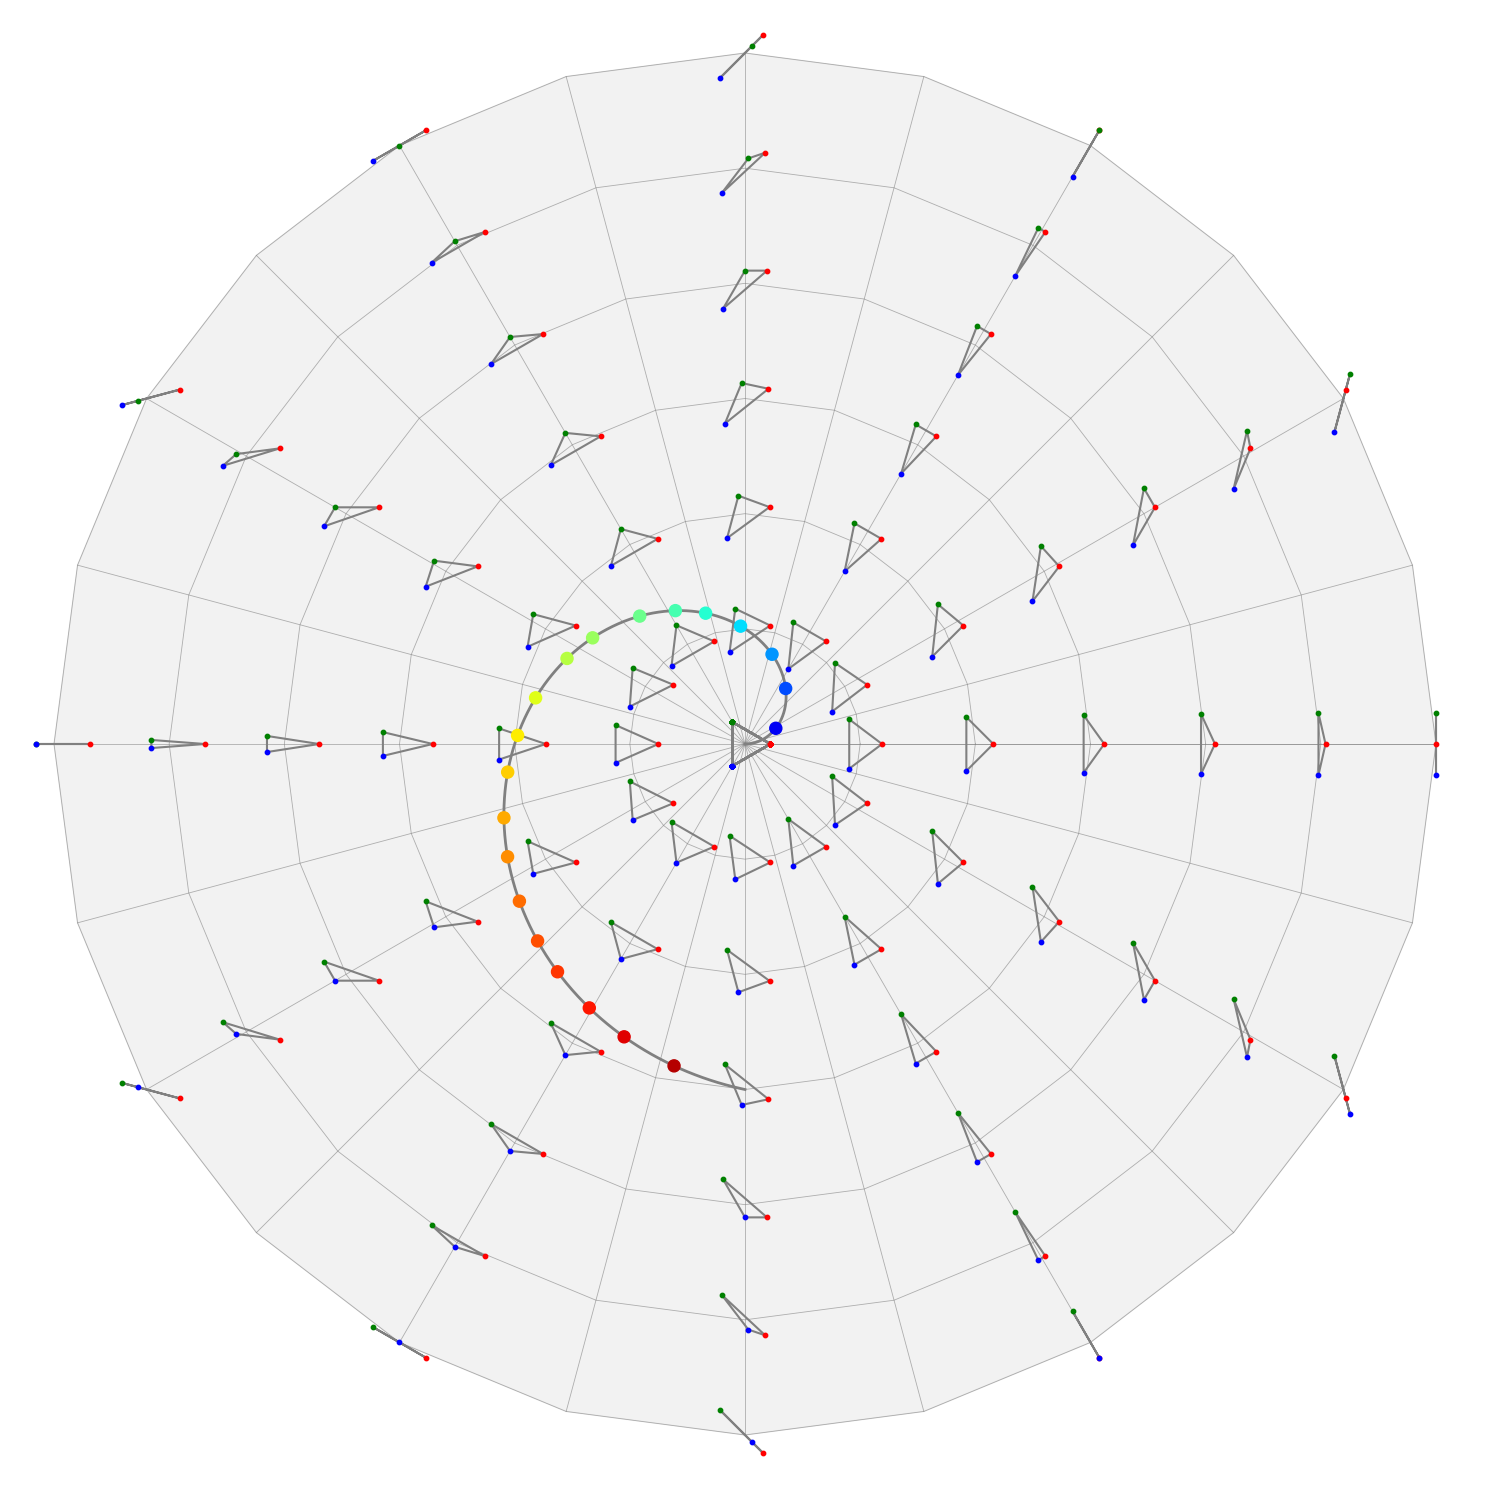

In [31]:
#Visualisation of the data
fig = plt.figure(figsize=(15, 15))
from matplotlib import cm
jet = cm.get_cmap('jet', 1000)
colors = jet(times / 1000.)

KD.draw()

KD.clear_points()
KD.add_points(model)
KD.draw_curve(color='grey', lw=2)

KD.clear_points()
KD.add_points(X)
KD.draw_points(color=colors, s=75, zorder=1)

In [32]:
k_neighbours=2

In [33]:
neighbours = KLLE.nearest_neighbours(points=X, k_neighbours=k_neighbours)
edges = []
for i in range(n_data):
    for j in neighbours[i]:
        edges.append((i, j))
neighbour_graph = nx.Graph(edges)
print(edges)
print(nx.is_connected(neighbour_graph))

neighbours = [[1, 2]] + [[i-1, i+1] for i in range(1, n_data - 1)]+[[n_data-3, n_data-2]]
print(neighbours)

[(0, np.int64(1)), (0, np.int64(2)), (1, np.int64(2)), (1, np.int64(0)), (2, np.int64(1)), (2, np.int64(3)), (3, np.int64(4)), (3, np.int64(2)), (4, np.int64(5)), (4, np.int64(3)), (5, np.int64(4)), (5, np.int64(6)), (6, np.int64(5)), (6, np.int64(7)), (7, np.int64(8)), (7, np.int64(6)), (8, np.int64(7)), (8, np.int64(9)), (9, np.int64(10)), (9, np.int64(8)), (10, np.int64(11)), (10, np.int64(9)), (11, np.int64(10)), (11, np.int64(12)), (12, np.int64(13)), (12, np.int64(11)), (13, np.int64(12)), (13, np.int64(14)), (14, np.int64(15)), (14, np.int64(13)), (15, np.int64(16)), (15, np.int64(14)), (16, np.int64(15)), (16, np.int64(17)), (17, np.int64(18)), (17, np.int64(16)), (18, np.int64(17)), (18, np.int64(19)), (19, np.int64(18)), (19, np.int64(17))]
True
[[1, 2], [0, 2], [1, 3], [2, 4], [3, 5], [4, 6], [5, 7], [6, 8], [7, 9], [8, 10], [9, 11], [10, 12], [11, 13], [12, 14], [13, 15], [14, 16], [15, 17], [16, 18], [17, 19], [17, 18]]


tensor([4.3303e-16, 9.3252e-06, 8.6530e-04, 5.4663e-03, 1.9829e-02, 5.8628e-02,
        1.4500e-01, 2.4826e-01, 4.2828e-01, 7.2617e-01, 9.7188e-01, 1.4232e+00,
        1.8987e+00, 2.4072e+00, 2.9560e+00, 3.3875e+00, 3.7150e+00, 3.9275e+00,
        7.8443e+00, 1.0089e+01])


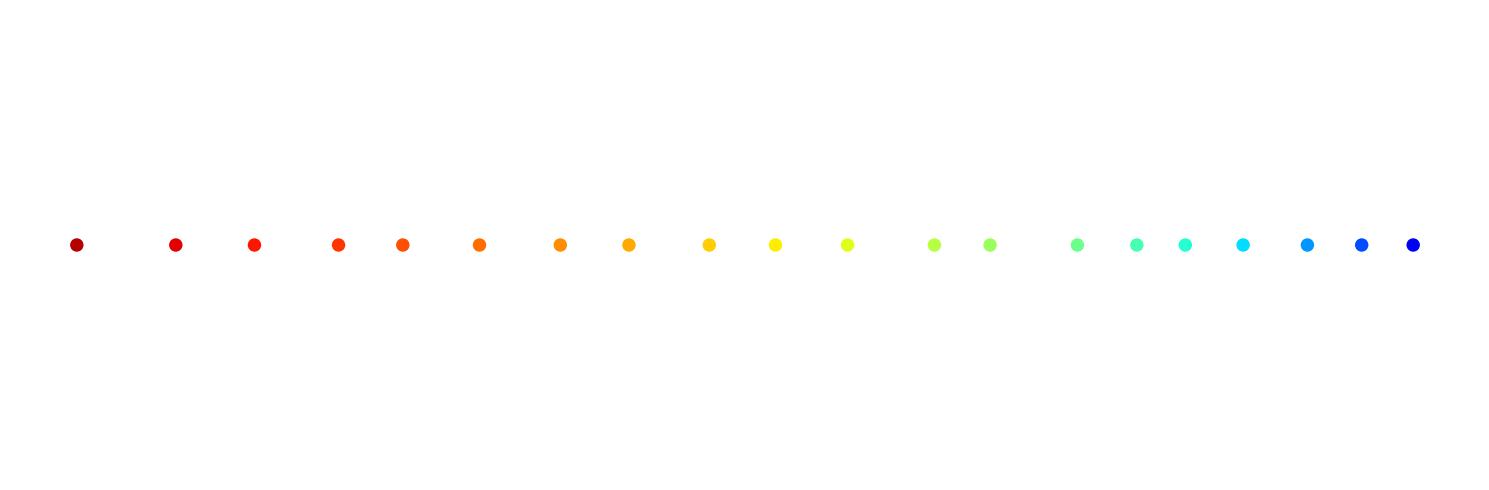

In [34]:
#Euclidean LLE
alpha=1E-15
W = gs.zeros((n_data, n_data))

for i in range(n_data):
    aligned = KLLE.hor_bundle.align(X[neighbours[i]], X[i])
    centred = gs.array([gs.flatten(x) for x in aligned]) - gs.flatten(X[i])
    covariance_mat = centred @ gs.transpose(centred)
    #covariance_mat = covariance_mat + alpha * gs.trace(covariance_mat) * gs.eye(k_neighbours)
    w = gs.linalg.inv(covariance_mat) @ gs.ones(k_neighbours)
    W[i, neighbours[i]] = w / gs.sum(w)

lle = KLLE.embedding_coordinates(weights=W, d_embedding=1)
sparse_mat = gs.transpose(gs.eye(n_data) - W) @ (gs.eye(n_data) - W)
[eigen_val, eigen_vec] = gs.linalg.eigh(sparse_mat)
print(eigen_val)

fig = plt.figure(figsize=(15, 5))

plt.scatter(lle, gs.zeros_like(lle), color=colors, s=75, alpha=1)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()

In [35]:
import warnings
warnings.filterwarnings('ignore')

In [36]:
#Method
rlle = KLLE.fit(points=X, k_neighbours=k_neighbours, d_embedding=1)

#Step 2: reconstruction weights
weights = gs.zeros((n_data, n_data))
projection_error = 0

for i in range(n_data):
    point = X[i]
    ref_points = KLLE.hor_bundle.align(X[neighbours[i]], point)
    centred = gs.array([gs.flatten(KLLE.metric.log(x, point)) for x in ref_points])
    covariance_mat = centred @ gs.transpose(centred)
    [eigen_val, eigen_vec] = gs.linalg.eigh(covariance_mat)
    #print(eigen_val)
    w0 = eigen_vec[0] / gs.sum(eigen_vec[0])
    a, u, v, w = KLLE.barycentric_projection(point, ref_points, n_steps=10, w0='critical')
    projection_error += KLLE.hor_metric.squared_norm(v)
    weights[i][neighbours[i]] = w

#Step 3: embedding coordinates
rlle = KLLE.embedding_coordinates(weights, d_embedding=1)
print(projection_error)

tensor(0.0010)


In [37]:
for i in range(n_data): 
    print(weights[i, neighbours[i]])
    print(W[i, neighbours[i]])

tensor([ 2.1717, -1.1717])
tensor([ 1.9084, -0.9084])
tensor([0.4666, 0.5334])
tensor([0.4698, 0.5302])
tensor([0.5366, 0.4634])
tensor([0.5348, 0.4652])
tensor([0.4658, 0.5342])
tensor([0.4669, 0.5331])
tensor([0.4461, 0.5538])
tensor([0.4471, 0.5529])
tensor([0.5433, 0.4567])
tensor([0.5428, 0.4572])
tensor([0.5916, 0.4084])
tensor([0.5902, 0.4098])
tensor([0.3839, 0.6161])
tensor([0.3851, 0.6149])
tensor([0.6061, 0.3939])
tensor([0.6052, 0.3948])
tensor([0.4506, 0.5494])
tensor([0.4507, 0.5493])
tensor([0.4756, 0.5244])
tensor([0.4757, 0.5243])
tensor([0.5461, 0.4539])
tensor([0.5458, 0.4542])
tensor([0.4585, 0.5415])
tensor([0.4587, 0.5413])
tensor([0.5393, 0.4607])
tensor([0.5392, 0.4608])
tensor([0.4860, 0.5140])
tensor([0.4860, 0.5140])
tensor([0.4550, 0.5450])
tensor([0.4551, 0.5449])
tensor([0.5664, 0.4336])
tensor([0.5662, 0.4338])
tensor([0.4830, 0.5170])
tensor([0.4831, 0.5169])
tensor([0.5596, 0.4404])
tensor([0.5594, 0.4406])
tensor([-1.2715,  2.2715])
tensor([-1.2561,  2

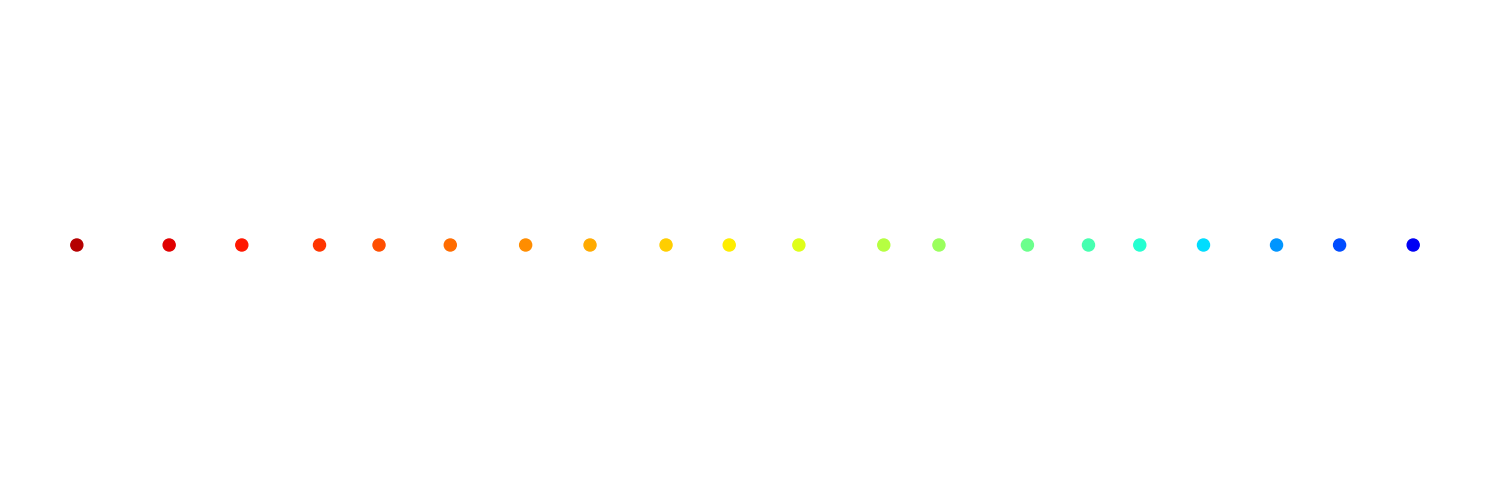

In [38]:
#Riemannian LLE
fig = plt.figure(figsize=(15, 5))

plt.scatter(rlle[0:], gs.zeros_like(rlle), color=colors, s=75, alpha=1)
plt.axis('equal')
plt.axis('off')
fig.tight_layout()

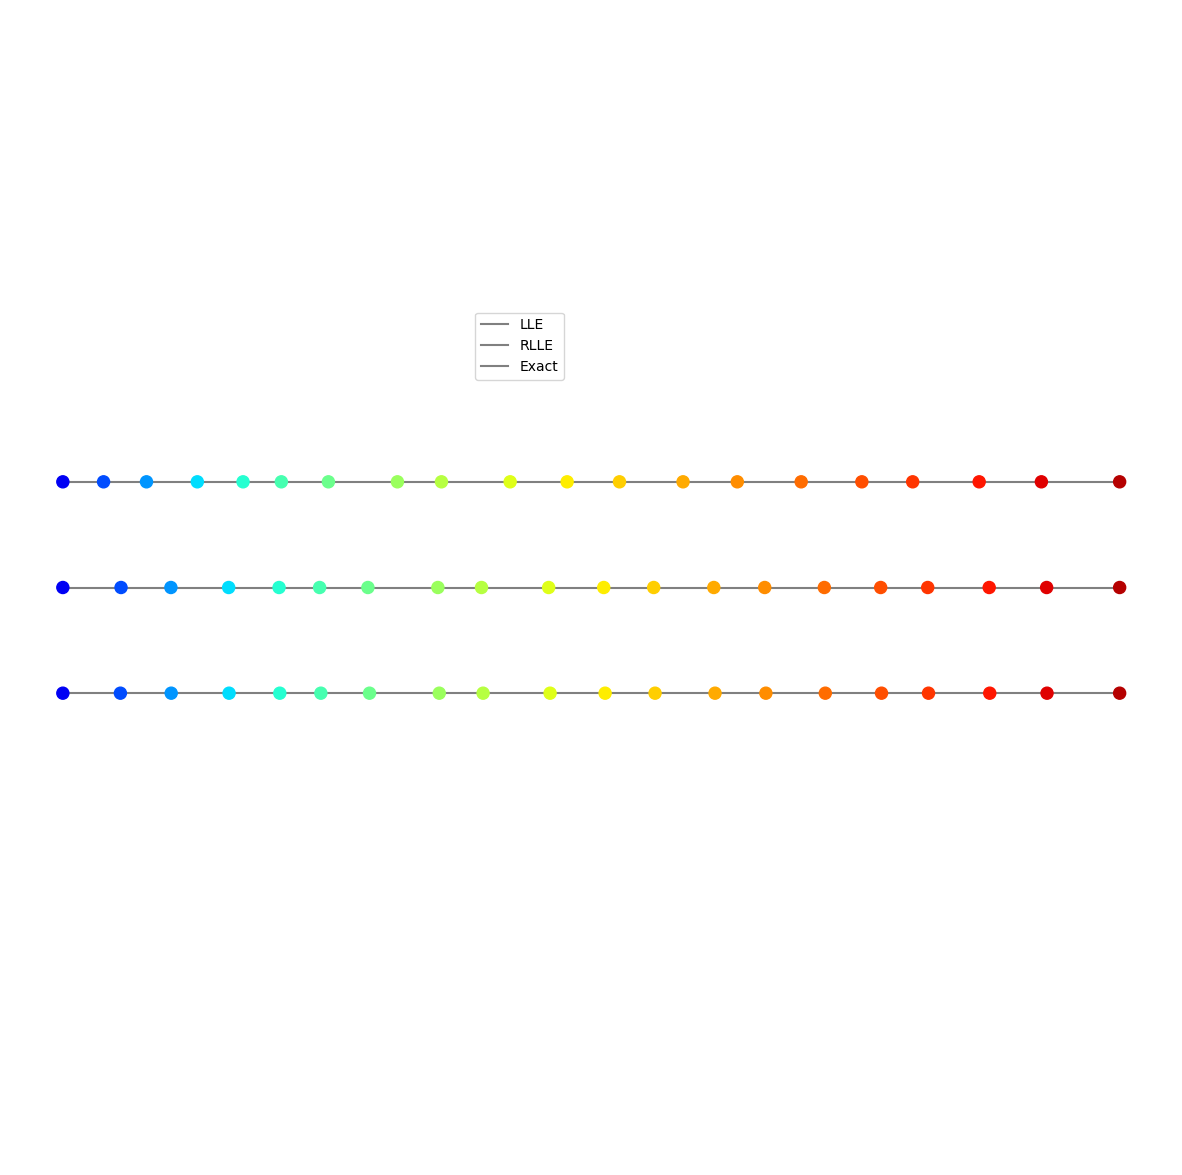

In [39]:
#Visualisation of the embedding
fig = plt.figure(figsize=(15, 15))
plt.axis('equal')
plt.axis('off')

#Model
flat_model = gs.linspace(0., 1., 100)
ee_line, = plt.plot(flat_model, gs.zeros(100), c='grey', zorder=-1)
ee = curv_ab[times]

#Re-scaling
rescaled_ee = 0. + 1. / (ee[-1] - ee[0]) * (ee - ee[0])
rescaled_rlle =  0. + 1. / (rlle[-1, 0] - rlle[0, 0]) * (rlle[:, 0] - rlle[0, 0])
rescaled_lle =  0. + 1. / (lle[-1, 0] - lle[0, 0]) * (lle[:, 0] - lle[0, 0])

#Exact embedding
plt.scatter(rescaled_ee, gs.zeros(n_data), marker='o', c=colors, alpha=1, s=75)

#LBE
rlle_line, = plt.plot(gs.linspace(0., 1., 100), .1 * gs.ones(100), c='grey', zorder=-1)
plt.scatter(rescaled_rlle, .1 * gs.ones(n_data), marker='o', c=colors, alpha=1, s=75)

#LLE
lle_line, = plt.plot(gs.linspace(0., 1., 100), .2 * gs.ones(100), c='grey', zorder=-1)
plt.scatter(rescaled_lle, .2 * gs.ones(n_data), marker='o', c=colors, alpha=1, s=75)

#Legend
plt.legend([lle_line, rlle_line, ee_line], ['LLE', 'RLLE', 'Exact'], loc=(.4, .68))

In [40]:
#Evaluation of the embedding
print("RLLE:", gs.linalg.norm(rescaled_rlle - rescaled_ee))
print("LLE:", gs.linalg.norm(rescaled_lle - rescaled_ee))

RLLE: tensor(0.0043)
LLE: tensor(0.1251)


#### Experiment

In [220]:
#Experience
import scipy.integrate as integrate

n_exp = 100
n_data = 20
k_neighbours = 2
neighbours = [[1, 2]] + [[i-1, i+1] for i in range(1, n_data - 1)]+[[n_data-3, n_data-2]]
lle, rlle_e, rlle_c, ee = [], [], [], []

radius = gs.linspace(0., gs.pi / 8, 1000)
theta = gs.linspace(0., 1.5 * gs.pi, 1000)
u_theta = gs.array([gs.cos(t) * KD.ua + gs.sin(t) * KD.na for t in theta])
model = gs.array([gs.hstack((gs.cos(r) * KD.pole + gs.sin(r) * u, gs.zeros((3, 1)))) 
                 for (r, u) in zip(radius, u_theta)])
curv_ab = gs.array([integrate.quad(lambda t: gs.sqrt(1. + 36. * gs.sin(t / 6) ** 2), 0., t_i)[0] for t_i in theta])

for k in range(n_exp):
    print(k)
    
    #Data
    times = (gs.linspace(100**(5./3.), 950**(5./3.), n_data))**(3./5.) + gs.random.normal(scale=5., size=n_data)
    times = gs.array([int(t) for t in times])
    X = model[times]
    ee.append(curv_ab[times])
    
    #neighbours = KLLE.nearest_neighbours(points=X, k_neighbours=k_neighbours)
    
    #Euclidean LLE
    W = gs.zeros((n_data, n_data))
    alpha=1E-15

    for i in range(n_data):
        aligned = KLLE.hor_bundle.align(X[neighbours[i]], X[i])
        centred = gs.array([gs.flatten(x) for x in aligned]) - gs.flatten(X[i])
        covariance_mat = centred @ gs.transpose(centred)
        covariance_mat = covariance_mat# + alpha * gs.trace(covariance_mat) * gs.eye(k_neighbours)
        w = gs.linalg.inv(covariance_mat) @ gs.ones(k_neighbours)
        W[i, neighbours[i]] = w / gs.sum(w)

    lle.append(KLLE.embedding_coordinates(weights=W, d_embedding=1)[:, 0])
    
    #Riemannian LLE, 'equal' initialization 
    #Step 2: reconstruction weights
    weights = gs.zeros((n_data, n_data))

    for i in range(n_data):
        point = X[i]
        ref_points = KLLE.hor_bundle.align(X[neighbours[i]], point)
        a, u, v, w = KLLE.barycentric_projection(point, ref_points, w0='equal')
        weights[i][neighbours[i]] = w

    #Step 3: embedding coordinates
    rlle_e.append(KLLE.embedding_coordinates(weights, d_embedding=1)[:, 0])
    
    #Riemannian LLE, 'critical' initialization 
    #Step 2: reconstruction weights
    weights = gs.zeros((n_data, n_data))

    for i in range(n_data):
        point = X[i]
        ref_points = KLLE.hor_bundle.align(X[neighbours[i]], point)
        a, u, v, w = KLLE.barycentric_projection(point, ref_points, w0='critical')
        weights[i][neighbours[i]] = w

    #Step 3: embedding coordinates
    rlle_c.append(KLLE.embedding_coordinates(weights, d_embedding=1)[:, 0])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28


KeyboardInterrupt: 

In [ ]:
lle_error = []

for y1, y2 in zip(ee, lle): 
    rescaled1 = 1. / (y1[-1] - y1[0]) * (y1 - y1[0])
    rescaled2 = 1. / (y2[-1] - y2[0]) * (y2[:] - y2[0])
    lle_error.append(gs.linalg.norm(gs.array(rescaled2) - gs.array(rescaled1)))
print(max(lle_error))

In [ ]:
#Results
lle_error, rlle_e_error, rlle_c_error = [], [], []

for y_1, y_2, y_3, y_4 in zip(ee, lle, rlle_e, rlle_c):
    
    rescaled_1 = 1. / (y_1[-1] - y_1[0]) * (y_1 - y_1[0])
    print(rescaled_1)
    rescaled_2 = 1. / (y_2[-1] - y_2[0]) * (y_2[:] - y_2[0])
    rescaled_3 = 1. / (y_3[-1] - y_3[0]) * (y_3[:] - y_3[0])
    rescaled_4 = 1. / (y_4[-1] - y_4[0]) * (y_4[:] - y_4[0])
    
    lle_error.append(gs.linalg.norm(gs.array(rescaled_2) - gs.array(rescaled_1)))
    rlle_e_error.append(gs.linalg.norm(gs.array(rescaled_3) - gs.array(rescaled_1)))
    rlle_c_error.append(gs.linalg.norm(gs.array(rescaled_4) - gs.array(rescaled_1)))
    
print("Average error of LLE =", gs.mean(gs.array(lle_error)))
print("Average error of RLLE 'equal'=", gs.mean(gs.array(rlle_e_error)))
print("Average error of RLLE 'critical'=", gs.mean(gs.array(rlle_c_error)))

In [ ]:
fig = plt.figure(figsize=(10, 15))
ax = plt.axes()
plt.boxplot([rlle_c_error, lle_error], sym='')
ax.get_xaxis().set_visible(False)

In [ ]:
fig = plt.figure(figsize=(15, 15))
plt.axis('equal')
plt.axis('off')
i = gs.argmax(gs.array(lle_error))
print(i, rlle_c_error[i])
print(ee[i])
colors = jet(ee[i] / curv_ab[-1])

rescaled_ee = 0. + 1. / (ee[i][-1] - ee[i][0]) * (ee[i] - ee[i][0])
rescaled_rlle_e =  0. + 1. / (rlle_e[i][-1] - rlle_e[i][0]) * (rlle_e[i][:] - rlle_e[i][0])
rescaled_rlle_c =  0. + 1. / (rlle_c[i][-1] - rlle_c[i][0]) * (rlle_c[i][:] - rlle_c[i][0])
rescaled_lle =  0. + 1. / (lle[i][-1] - lle[i][0]) * (lle[i][:] - lle[i][0])

#Exact embedding
plt.scatter(rescaled_ee, gs.zeros(n_data), marker='o', c=colors, alpha=1, s=75)

#LBE
plt.scatter(rescaled_rlle_c, .1 * gs.ones(n_data), marker='o', c=colors, alpha=1, s=75)

#LBE
#plt.scatter(rescaled_rlle_e, .2 * gs.ones(n_data), marker='o', c=colors, alpha=1, s=75)

#LLE
plt.scatter(rescaled_lle, .2 * gs.ones(n_data), marker='o', c=colors, alpha=1, s=75)

#Legend
plt.legend([lle_line, rlle_line, ee_line], ['LLE', 'RLLE', 'Exact'], loc=(.4, .68))

In [ ]:
#Visualisation of the data
times = gs.array([list(curv_ab).index(c) for c in ee[i]])
X = model[times]

fig = plt.figure(figsize=(15, 15))
from matplotlib import cm
jet = cm.get_cmap('jet', 1000)
colors = jet(times / 1000.)

KD.draw()

KD.clear_points()
KD.add_points(model)
KD.draw_curve(color='grey', lw=2)

KD.clear_points()
KD.add_points(X)
KD.draw_points(color=colors, s=75, zorder=1)

# References

[KDLS2021] Kim, K. R., Dryden, I. L., Le, H., & Severn, K. E. 
Smoothing splines on Riemannian manifolds, with applications to 3D shape space.
Journal of the Royal Statistical Society: Series B (Statistical Methodology), 2021, vol. 83, no 1, p. 108-132.
https://doi.org/10.1111/rssb.12402

[B2008] Dimitri. P. Bertsekas. 
Nonlinear programming. 
2d ed., 3rd print. Belmont, Massachusetts: Athena Scientific, 2008.
https://doi.org/10.1057/palgrave.jors.2600425

[RS2000] Roweis, S. T., & Saul, L. K. (2000). 
Nonlinear dimensionality reduction by locally linear embedding. 
science, 290(5500), 2323-2326.
https://doi.org/10.1126/science.290.5500.2323